In [6]:
# PCA analysis

### Imports

In [7]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [8]:
FOLDERS = {
    "../data/03_hammer_tests/test_01/00_intact": "No fracture hammer 1",
    "../data/03_hammer_tests/test_01/100_fractured": "100% Fracture hammer 1",
    "../data/03_hammer_tests/test_02/00_intact": "No fracture hammer 2",
    "../data/03_hammer_tests/test_02/100_fractured": "100% Fracture hammer 2",
    "../data/03_hammer_tests/test_03/00_intact": "No fracture hammer 3",
    "../data/03_hammer_tests/test_03/100_fractured": "100% Fracture hammer 3",
    "../data/03_hammer_tests/test_04/00_intact": "No fracture hammer 4",
    "../data/03_hammer_tests/test_04/100_fractured": "100% Fracture hammer 4"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(csv_files)
    }

    print(f"{label}: {len(impedances)} files loaded")

No fracture hammer 1: 6 files loaded
100% Fracture hammer 1: 15 files loaded
No fracture hammer 2: 11 files loaded
100% Fracture hammer 2: 14 files loaded
No fracture hammer 3: 7 files loaded
100% Fracture hammer 3: 7 files loaded
No fracture hammer 4: 9 files loaded
100% Fracture hammer 4: 9 files loaded


### Outlier detection

In [9]:
print("OUTLIER REPORT")
print("=" * 40)

for group_name, data in group_data.items():

    sweep_means = np.mean(
        data["raw"],
        axis=1
    )

    z_scores = np.abs(
        zscore(sweep_means)
    )

    outliers = np.where(
        z_scores > 2.5
    )[0]

    print(f"\n{group_name}")

    if len(outliers) == 0:
        print("No outliers found")

    else:
        print(f"Outliers: {outliers}")

OUTLIER REPORT

No fracture hammer 1
No outliers found

100% Fracture hammer 1
No outliers found

No fracture hammer 2
Outliers: [3]

100% Fracture hammer 2
Outliers: [9]

No fracture hammer 3
No outliers found

100% Fracture hammer 3
No outliers found

No fracture hammer 4
Outliers: [0]

100% Fracture hammer 4
No outliers found


### PCA Analysis

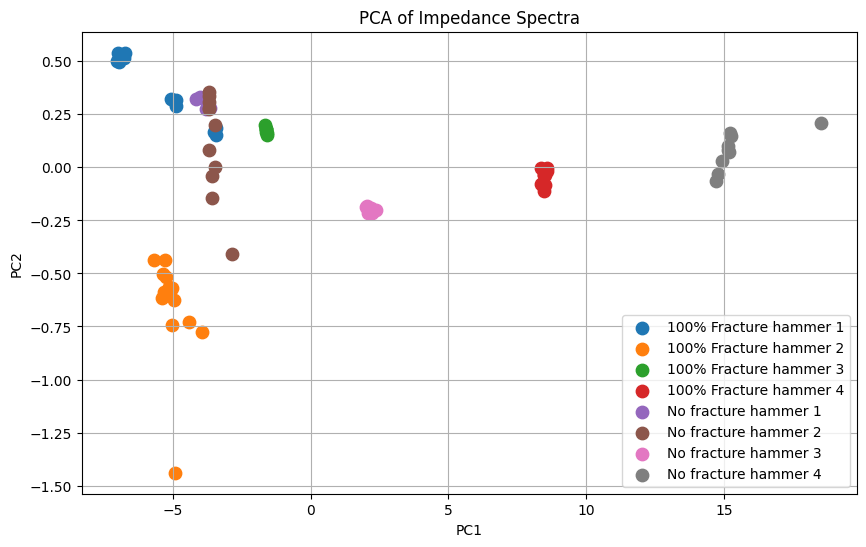

In [10]:
X = []
y = []

for group_name, data in group_data.items():

    for sweep in data["raw"]:
        X.append(sweep)
        y.append(group_name)

X = np.array(X)

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.style.use("default")

plt.figure(figsize=(10, 6))

for group_name in np.unique(y):
    mask = np.array(y) == group_name

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=80,
        label=group_name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Impedance Spectra")
plt.legend()
plt.grid()

plt.savefig(
    "pca comparison hammer test.png",
    dpi=300
)

plt.show()

### extra PCA

In [11]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))


[0.9958892 0.0028425]
0.9987316972405277


In [12]:
print(plt.rcParams['figure.facecolor'])
print(plt.rcParams['axes.facecolor'])

white
white


In [13]:
pca = PCA()
pca.fit(X)

print(pca.explained_variance_ratio_)

[9.95889202e-01 2.84249545e-03 1.04920334e-03 6.85497381e-05
 3.61924077e-05 2.82888565e-05 1.60789018e-05 1.32590503e-05
 7.01496567e-06 6.64848132e-06 5.31766732e-06 4.27307280e-06
 3.90770314e-06 3.21251264e-06 3.10679942e-06 3.00113158e-06
 2.11228064e-06 1.95450801e-06 1.62925511e-06 1.52334313e-06
 1.43559037e-06 1.33709118e-06 1.15363785e-06 9.54358351e-07
 8.63960379e-07 8.18414591e-07 7.15078850e-07 6.43726868e-07
 5.96621684e-07 5.33039377e-07 4.73132133e-07 4.46491273e-07
 3.85840255e-07 3.45535854e-07 3.24446705e-07 2.80851633e-07
 2.64613967e-07 2.17449171e-07 1.83660743e-07 1.70245113e-07
 1.59784771e-07 1.36794370e-07 1.26979365e-07 1.07325092e-07
 1.04812414e-07 6.85418351e-08 4.79628194e-08 4.39999552e-08
 3.56929370e-08 3.15615090e-08 2.15015498e-08]


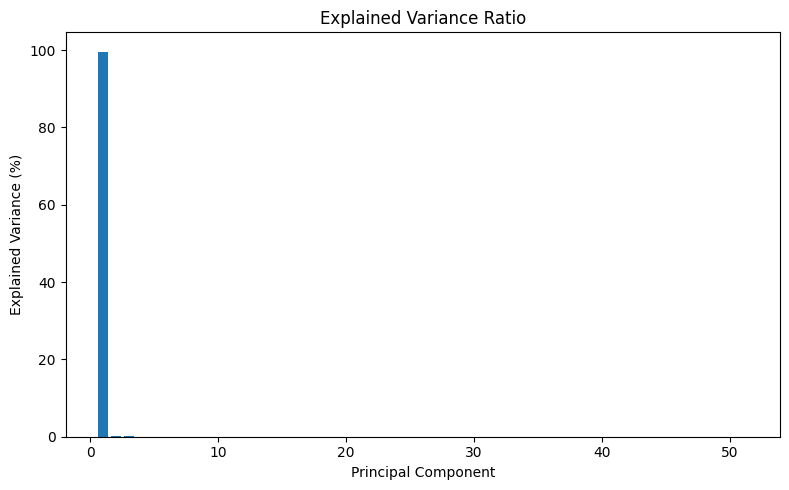

In [14]:
import matplotlib.pyplot as plt
import numpy as np

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(explained)+1),
    explained * 100
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance Ratio")

plt.tight_layout()
plt.savefig("../figures/not_in_paper/04_PCA_analysis_bar_graph.png", dpi=300)
plt.show()